# 01 · Seeing site-level heterogeneity
**Workshop: Beyond Interoperability — Federated ML for Research Data Curation**

Interoperability lets data cross institutional lines. It does *not* guarantee that a variable *means* the same thing at every site. Before we integrate any data or models, we quantify how the four hospitals in the UCI Heart Disease federation differ, and we separate two very different phenomena:

* **True distributional shift** — the populations genuinely differ (e.g. disease prevalence).
* **Measurement-induced heterogeneity** — the *measurement process* differs (e.g. a site never recorded serum cholesterol).


In [1]:
# --- workshop bootstrap: make the package importable ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))
import numpy as np, pandas as pd
from fedconformal import data, conformal, evaluate as ev, federated, heterogeneity as het, viz, eda, paper_figures as pf
viz.set_style()
%matplotlib inline
# load the federation once (each notebook is self-contained)
df = data.load_raw()
sites = data.load_sites(shared_scaler=True)

## The four sites
Cleveland, Hungary, Switzerland (Zurich/Basel) and the V.A. Long Beach each ran the *same* case-report form. That is what makes this dataset a natural federation.

In [2]:
df = data.load_raw()
sites = data.load_sites(shared_scaler=True)
summary = data.summarize_sites(sites, df)
summary

,site,label,n,n_classes,prevalence,majority_class,majority_share,mean_age,chol_unrecorded_frac,ca_missing_frac,thal_missing_frac
0,cleveland,Cleveland Clinic,303,5,0.459,No disease,0.541,54.4,0.000,0.013,0.007
1,hungarian,Hungarian Inst. of Cardiology,294,5,0.361,No disease,0.639,47.8,0.000,0.986,0.905
2,switzerland,Univ. Hospital Zurich (Switzerland),123,5,0.935,Mild,0.390,55.3,1.000,0.959,0.423
3,va,V.A. Long Beach,200,5,0.745,Mild,0.280,59.4,0.245,0.990,0.830


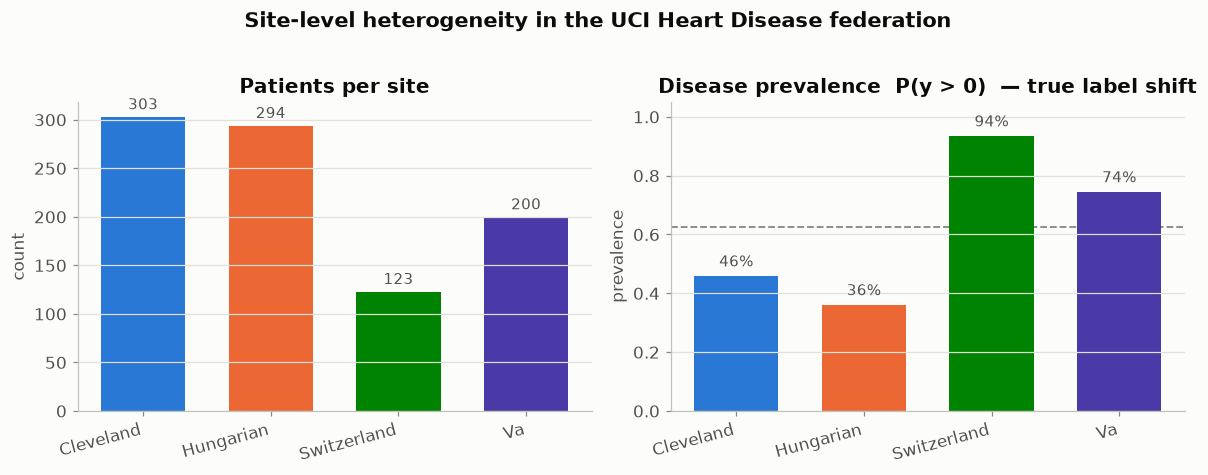

In [3]:
viz.plot_site_overview(summary);

Notice prevalence swings from **36% (Hungary)** to **94% (Switzerland)** — a large *true* label shift driven by referral patterns (Switzerland is a tertiary cardiac centre).

## Measurement-induced heterogeneity
A cholesterol of exactly 0 mg/dl is not a measurement — it is an *unrecorded* value, coded that way directly in the source files. `ca` (# vessels by fluoroscopy) and `thal` (thallium stress test) are coded `?` / `-9` in the raw files and load as genuine missing values. Watch which sites simply did not record certain labs — and how much more of the panel that covers than just cholesterol.

,chol,trestbps,thalach,ca,thal
site,,,,,
cleveland,0%,0%,0%,1%,1%
hungarian,0%,0%,0%,99%,90%
switzerland,100%,0%,0%,96%,42%
va,24%,0%,0%,99%,83%


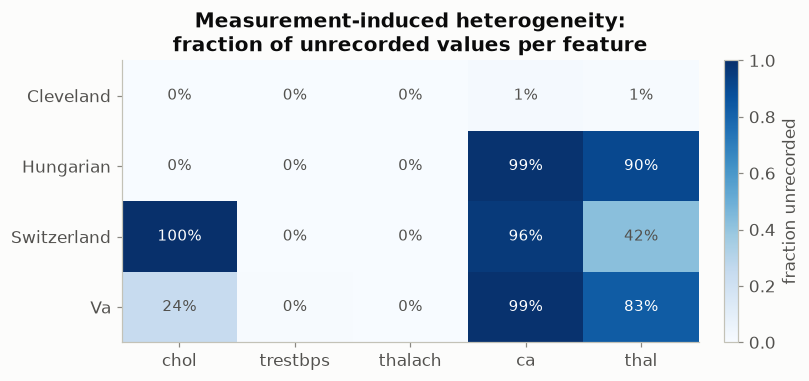

In [4]:
miss = het.missingness_report(df)
display(miss.style.format('{:.0%}'))
viz.plot_missingness(miss);

**Switzerland never recorded cholesterol (100% unrecorded)** — a curation error, not biology, if pooled naively. But look at `ca` and `thal`: **98%+ missing at every site except Cleveland.** Any model using those two features is, outside Cleveland, almost entirely running on the mean-imputed value. That is a measurement-heterogeneity trap far bigger than cholesterol, and it is easy to miss if you only look at accuracy.

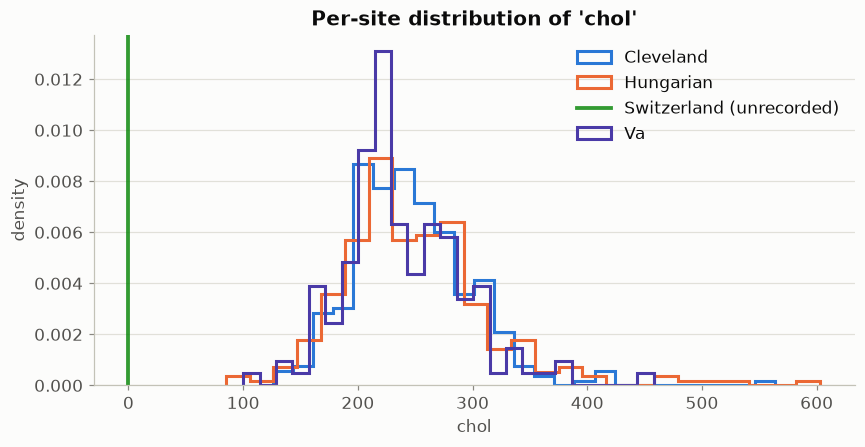

In [5]:
viz.plot_feature_distributions(df, 'chol');

## A single-number covariate-shift alarm
Train a classifier to guess *which site* a patient came from. If it cannot do better than chance (AUC ≈ 0.5) the sites are exchangeable; AUC ≈ 1.0 signals strong covariate shift.

,cleveland,hungarian,switzerland,va
cleveland,0.50,0.89,1.00,0.88
hungarian,0.89,0.50,1.00,0.93
switzerland,1.00,1.00,0.50,0.88
va,0.88,0.93,0.88,0.50


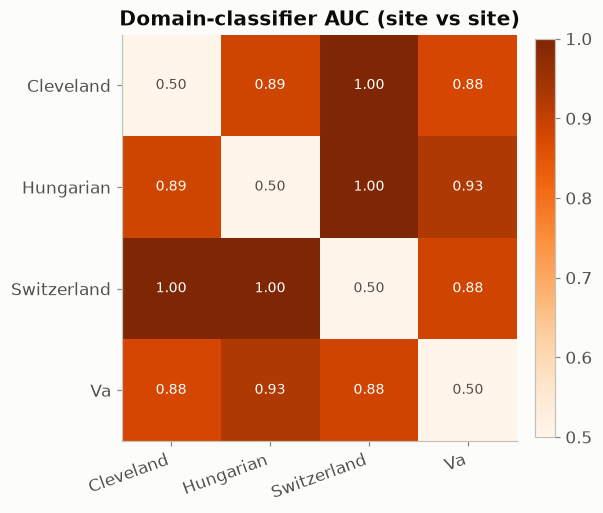

In [6]:
auc = het.domain_auc_matrix(sites)
display(auc.round(2))
viz.plot_divergence_matrix(auc, 'Domain-classifier AUC (site vs site)', cmap='Oranges');

Every off-diagonal AUC is **0.93–1.00**: a model can almost perfectly tell any two sites apart. This is exactly the setting where a model — or a calibration — from one site is at risk of failing silently at another. That is what the next notebooks make precise.

### Exercise
1. Swap `shared_scaler=True` for `False` in `load_sites` and re-plot. What does per-site standardization *hide*?
2. Compute `het.js_divergence_matrix(df, 'age')` and compare with `'thalach'`. Which feature is most shifted across sites?